<a href="https://colab.research.google.com/github/hanna04107-wq/CPI-PREDICTION-USING-MACROECONOMIC-INDICATORS-AND-MACHINE-LEARNING-MODEL/blob/main/testing_for_overall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/FYP CODES/Final_Dataset_2013_2026_Jan.csv")

In [3]:
df

,Date,Year,Month,CPI_Index,OPR_Rate,Unemployment_Rate,M3_Total,PPI_Index,USD_Avg
0,2013-01-01,2013,1,105.9,3.00,3.4,1375858.0,107.9,3.0390
1,2013-02-01,2013,2,106.1,3.00,3.0,1379389.6,109.6,3.0978
2,2013-03-01,2013,3,106.2,3.00,3.2,1392122.9,108.2,3.1076
3,2013-04-01,2013,4,106.3,3.00,3.0,1399798.9,107.3,3.0498
4,2013-05-01,2013,5,106.6,3.00,3.2,1414632.1,106.6,3.0168
...,...,...,...,...,...,...,...,...,...
152,2025-09-01,2025,9,135.2,2.75,3.0,2522834.6,116.0,4.2126
153,2025-10-01,2025,10,135.1,2.75,3.0,2546954.1,116.0,4.2160
154,2025-11-01,2025,11,135.1,2.75,2.9,2550062.5,115.6,4.1559
155,2025-12-01,2025,12,135.5,2.75,2.9,2591321.8,115.4,4.0919


# **ARIMA Analysis in CPI & Macroeconomy data**

In [ ]:
df.describe()

,Year,Month,CPI_Index,OPR_Rate,Unemployment_Rate,M3_Total,PPI_Index,USD_Avg
count,157.000000,157.000000,157.000000,157.000000,157.000000,1.570000e+02,157.000000,157.000000
mean,2019.044586,6.464968,121.282803,2.816879,3.476433,1.939963e+06,110.154777,4.086168
std,3.783134,3.479848,8.287225,0.497898,0.548908,3.558274e+05,6.764997,0.438620
min,2013.000000,1.000000,105.900000,1.750000,2.600000,1.375858e+06,99.000000,3.016800
25%,2016.000000,3.000000,114.800000,2.750000,3.200000,1.611143e+06,105.000000,4.026900
50%,2019.000000,6.000000,120.900000,3.000000,3.300000,1.913308e+06,108.300000,4.177600
75%,2022.000000,9.000000,128.600000,3.250000,3.500000,2.257146e+06,116.300000,4.348100
max,2026.000000,12.000000,135.700000,3.250000,5.300000,2.591322e+06,124.100000,4.772300


In [ ]:
import pandas as pd
import warnings
from statsmodels.tsa.stattools import kpss

# 1. Abaikan amaran
warnings.filterwarnings("ignore")

# 2. Fungsi Ujian KPSS
def run_kpss_test(dataframe):
    print("=== Ujian Kepegunan KPSS (Kwiatkowski-Phillips-Schmidt-Shin) ===\n")
    print("Nota: H0 = Data adalah Pegun. Jika p-value <= 0.05, tolak H0 (Data Tidak Pegun).\n")

    for column in dataframe.columns:
        series = dataframe[column].dropna()
        # Menjalankan ujian KPSS
        kpss_stat, p_value, lags, crit = kpss(series, regression='c')

        # Penentuan status
        if p_value <= 0.05:
            status = "TIDAK PEGUN (Perlu Differencing)"
        else:
            status = "PEGUN (Sedia untuk Model)"

        print(f"Pembolehubah: {column:<18} | p-value: {p_value:.4f} | Status: {status}")

# ==========================================
# 3. PROSES DATA 'df' ANDA
# ==========================================
# Buat salinan supaya data asal 'df' tidak terganggu
df_kpss = df.copy()

# Langkah A: Pastikan lajur Date dibaca sebagai format masa sebenar, kemudian jadikan ia Index
df_kpss['Date'] = pd.to_datetime(df_kpss['Date'])
df_kpss = df_kpss.set_index('Date')

# Langkah B: Buang lajur Year dan Month
df_kpss = df_kpss.drop(columns=['Year', 'Month'])

# ==========================================
# 4. JALANKAN UJIAN
# ==========================================
run_kpss_test(df_kpss)

=== Ujian Kepegunan KPSS (Kwiatkowski-Phillips-Schmidt-Shin) ===

Nota: H0 = Data adalah Pegun. Jika p-value <= 0.05, tolak H0 (Data Tidak Pegun).

Pembolehubah: CPI_Index          | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: OPR_Rate           | p-value: 0.0414 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: Unemployment_Rate  | p-value: 0.0805 | Status: PEGUN (Sedia untuk Model)
Pembolehubah: M3_Total           | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: PPI_Index          | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: USD_Avg            | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)


In [ ]:
# ==========================================
# 2. ASINGKAN X DAN Y
# ==========================================
# Sasaran (Target)
y = df_model['CPI_Index']

# Ciri-ciri Makroekonomi (Features)
X = df_model.drop(columns=['CPI_Index'])

In [ ]:
from statsmodels.tsa.stattools import kpss
import warnings

# Abaikan amaran dari statsmodels untuk output yang lebih kemas
warnings.filterwarnings("ignore")

# Senaraikan pembolehubah yang ingin diuji (Kecualikan lajur Tarikh jika ia adalah index)
pembolehubah = ['CPI_Index', 'OPR_Rate', 'Unemployment_Rate', 'M3_Total', 'PPI_Index', 'USD_Avg']

print("=== Ujian Kepegunan Data: KPSS ===")
print("Nota: H0 = Data adalah Pegun. Jika p-value < 0.05, tolak H0 (Data Tidak Pegun).\n")

# Senarai untuk menyimpan pembolehubah yang gagal ujian (tidak pegun)
senarai_tidak_pegun = []

# 1. Jalankan Ujian KPSS
for var in pembolehubah:
    # Memastikan tiada nilai kosong (NaN) yang mengganggu ujian
    siri_data = df[var].dropna()

    # Menjalankan ujian KPSS (regression='c' bermaksud kita menguji pada paras purata/level)
    kpss_stat, p_value, lags, crit = kpss(siri_data, regression='c')

    if p_value < 0.05:
        status = "TIDAK PEGUN (Perlu Pembezaan)"
        senarai_tidak_pegun.append(var)
    else:
        status = "PEGUN (Sedia untuk Ujian Korelasi)"

    # Memaparkan hasil dengan kemas
    print(f"Pembolehubah: {var:<18} | p-value: {p_value:.4f} | Status: {status}")

# 2. Transformasi: Pembezaan (First Difference)
print("\n=== Proses Transformasi ===")
# Buat salinan data baharu khas untuk data yang telah dipegunkan
df_pegun = df.copy()

if len(senarai_tidak_pegun) > 0:
    print(f"Pembolehubah berikut didapati tidak pegun dan akan melalui proses pembezaan (differencing):")
    for var in senarai_tidak_pegun:
        print(f"- {var}")
        # Mengaplikasikan transformasi perbezaan pertama
        df_pegun[var] = df_pegun[var].diff()

    # Membuang baris pertama yang menjadi NaN selepas proses pembezaan
    df_pegun = df_pegun.dropna()
    print("\nTransformasi pembezaan selesai. Set data 'df_pegun' kini sedia digunakan.")
else:
    print("Semua data didapati pegun. Tiada transformasi pembezaan diperlukan.")

# (Pilihan) Semak struktur data baharu
print(f"\nBentuk data asal: {df.shape}")
print(f"Bentuk data selepas pembezaan (df_pegun): {df_pegun.shape}")

=== Ujian Kepegunan Data: KPSS ===
Nota: H0 = Data adalah Pegun. Jika p-value < 0.05, tolak H0 (Data Tidak Pegun).

Pembolehubah: CPI_Index          | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Pembezaan)
Pembolehubah: OPR_Rate           | p-value: 0.0414 | Status: TIDAK PEGUN (Perlu Pembezaan)
Pembolehubah: Unemployment_Rate  | p-value: 0.0805 | Status: PEGUN (Sedia untuk Ujian Korelasi)
Pembolehubah: M3_Total           | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Pembezaan)
Pembolehubah: PPI_Index          | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Pembezaan)
Pembolehubah: USD_Avg            | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Pembezaan)

=== Proses Transformasi ===
Pembolehubah berikut didapati tidak pegun dan akan melalui proses pembezaan (differencing):
- CPI_Index
- OPR_Rate
- M3_Total
- PPI_Index
- USD_Avg

Transformasi pembezaan selesai. Set data 'df_pegun' kini sedia digunakan.

Bentuk data asal: (157, 9)
Bentuk data selepas pembezaan (df_pegun): (156, 9)


=== Pra-pemprosesan Lajur Masa ===
- Lajur Tarikh telah ditukar menjadi Index.
- Lajur 'Year' telah dibuang.
- Lajur 'Month' telah dibuang.

=== 1. Ujian Korelasi (Pearson) ===


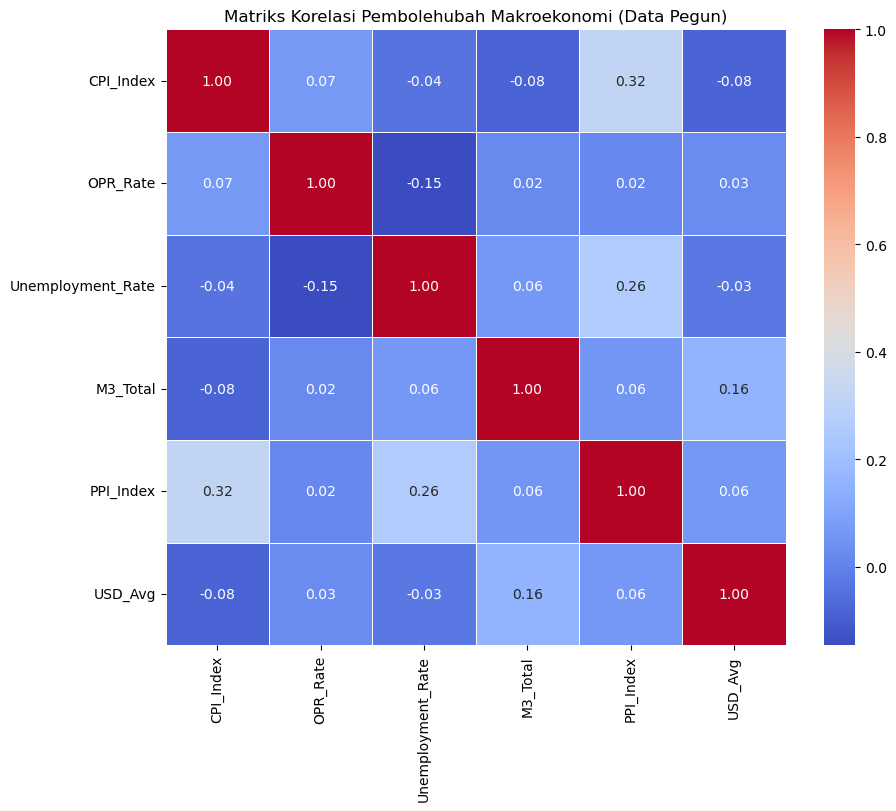


=== 2. Ujian Multikolineariti (VIF) ===


,Pembolehubah,Nilai VIF
1,OPR_Rate,1.026235
2,Unemployment_Rate,1.104558
3,M3_Total,1.032218
4,PPI_Index,1.081443
5,USD_Avg,1.031909



Nota Analisis: Jika Nilai VIF melebihi 10, wujud masalah multikolineariti yang serius.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("=== Pra-pemprosesan Lajur Masa ===")
# 1. Pastikan nama lajur tarikh anda betul (Contoh: 'Date' atau 'date')
# Jika huruf kecil, tukar perkataan 'Date' di bawah kepada 'date'
if 'Date' in df_pegun.columns:
    df_pegun['Date'] = pd.to_datetime(df_pegun['Date'])
    df_pegun = df_pegun.set_index('Date')
    print("- Lajur Tarikh telah ditukar menjadi Index.")

# 2. Buang lajur Year dan Month (dan sebarang lajur bukan nombor yang lain)
lajur_untuk_dibuang = ['Year', 'Month', 'year', 'month']
for lajur in lajur_untuk_dibuang:
    if lajur in df_pegun.columns:
        df_pegun = df_pegun.drop(columns=[lajur])
        print(f"- Lajur '{lajur}' telah dibuang.")

print("\n=== 1. Ujian Korelasi (Pearson) ===")
# Kini df_pegun hanya mengandungi nombor, peta haba akan berjaya dijana
plt.figure(figsize=(10, 8))
sns.heatmap(df_pegun.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Pembolehubah Makroekonomi (Data Pegun)")
plt.show()

print("\n=== 2. Ujian Multikolineariti (VIF) ===")
# Asingkan Pembolehubah Sasaran (Y) dan Pembolehubah Bebas (X)
y = df_pegun['CPI_Index']
X = df_pegun.drop(columns=['CPI_Index'])

# Tambahkan pemalar (constant) wajib untuk pengiraan VIF dan OLS
X_with_const = sm.add_constant(X)

# Pengiraan VIF
vif_data = pd.DataFrame()
vif_data["Pembolehubah"] = X_with_const.columns
vif_data["Nilai VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

# Paparkan jadual (kecualikan nilai 'const' kerana ia tidak relevan)
jadual_vif = vif_data[vif_data["Pembolehubah"] != 'const']
display(jadual_vif)

print("\nNota Analisis: Jika Nilai VIF melebihi 10, wujud masalah multikolineariti yang serius.")

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

print("=== 3. Latihan Model OLS (Ordinary Least Squares) ===")
# Menggunakan y dan X_with_const dari kod VIF tadi
model_ols = sm.OLS(y, X_with_const).fit()

# Simpan ralat (residuals) untuk Semakan Kecukupan nanti
ralat_ols = model_ols.resid
print(model_ols.summary())

print("\n" + "="*50 + "\n")

print("=== 4. Latihan Model ARIMA ===")
# Nota: ARIMA(1,0,1) digunakan sebagai contoh garis dasar awal.
# Nilai d=0 kerana siri masa y (CPI) sepatutnya sudah dipegunkan dalam langkah KPSS.
model_arima = ARIMA(y, order=(1, 0, 1)).fit()

# Simpan ralat ARIMA
ralat_arima = model_arima.resid
print(model_arima.summary())

=== 3. Latihan Model OLS (Ordinary Least Squares) ===
                            OLS Regression Results                            
Dep. Variable:              CPI_Index   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     4.793
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           0.000429
Time:                        09:12:06   Log-Likelihood:                -104.43
No. Observations:                 156   AIC:                             220.9
Df Residuals:                     150   BIC:                             239.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [ ]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

def semak_kecukupan_model(ralat, data_X=None, nama_model="Model"):
    print(f"\n--- Semakan Diagnostik untuk {nama_model} ---")

    # 1. Ujian Kenormalan (Shapiro-Wilk)
    # H0: Ralat bertaburan normal (Kita mahu p-value > 0.05)
    stat_norm, p_norm = shapiro(ralat)
    status_norm = "LULUS" if p_norm > 0.05 else "GAGAL (Tidak Normal)"
    print(f"1. Kenormalan (Shapiro-Wilk)  : p-value = {p_norm:.4f} -> {status_norm}")

    # 2. Ujian Bersandaran / Autokorelasi (Ljung-Box)
    # H0: Tiada autokorelasi dalam ralat (Kita mahu p-value > 0.05)
    lb_test = acorr_ljungbox(ralat, lags=[10], return_df=True)
    p_auto = lb_test['lb_pvalue'].iloc[0]
    status_auto = "LULUS" if p_auto > 0.05 else "GAGAL (Wujud Autokorelasi)"
    print(f"2. Bersandaran (Ljung-Box)    : p-value = {p_auto:.4f} -> {status_auto}")

    # 3. Ujian Homoskedastisiti (Breusch-Pagan) - Khas untuk OLS
    # H0: Varians adalah malar/homoskedastik (Kita mahu p-value > 0.05)
    if data_X is not None:
        bp_test = het_breuschpagan(ralat, data_X)
        p_homo = bp_test[1]
        status_homo = "LULUS" if p_homo > 0.05 else "GAGAL (Heteroskedastisiti)"
        print(f"3. Homoskedastisiti (B-Pagan) : p-value = {p_homo:.4f} -> {status_homo}")

# Jalankan semakan ke atas ralat model kita
print("=== 5. Semakan Kecukupan Model ===")
semak_kecukupan_model(ralat_ols, X_with_const, "Model OLS")
semak_kecukupan_model(ralat_arima, None, "Model ARIMA")

=== 5. Semakan Kecukupan Model ===

--- Semakan Diagnostik untuk Model OLS ---
1. Kenormalan (Shapiro-Wilk)  : p-value = 0.0000 -> GAGAL (Tidak Normal)
2. Bersandaran (Ljung-Box)    : p-value = 0.0132 -> GAGAL (Wujud Autokorelasi)
3. Homoskedastisiti (B-Pagan) : p-value = 0.0005 -> GAGAL (Heteroskedastisiti)

--- Semakan Diagnostik untuk Model ARIMA ---
1. Kenormalan (Shapiro-Wilk)  : p-value = 0.0000 -> GAGAL (Tidak Normal)
2. Bersandaran (Ljung-Box)    : p-value = 0.8176 -> LULUS


In [ ]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.tsa.stattools import kpss

warnings.filterwarnings("ignore")

print("=== FASA PEMBETULAN: Transformasi Logaritma (Natural Log) ===\n")

# 1. PENYELESAIAN RALAT: Kita bermula dari 'df' asal (data asal dari CSV)
# Ini memastikan kita tidak bergantung pada nama pembolehubah lama yang mungkin hilang
df_log = df.copy()

# 2. Pastikan Tarikh menjadi Index dan buang lajur Tahun/Bulan jika ada
if 'Date' in df_log.columns:
    df_log['Date'] = pd.to_datetime(df_log['Date'])
    df_log = df_log.set_index('Date')

for lajur in ['Year', 'Month', 'year', 'month']:
    if lajur in df_log.columns:
        df_log = df_log.drop(columns=[lajur])

# 3. Kenakan Log pada pembolehubah tahap (levels) sahaja
# Kita tidak menukar OPR dan Pengangguran kerana ia sudah dalam bentuk peratusan/kadar
pembolehubah_untuk_log = ['CPI_Index', 'M3_Total', 'PPI_Index', 'USD_Avg']

print("Melakukan transformasi Log ke atas:")
for var in pembolehubah_untuk_log:
    print(f"- {var}")
    # np.log adalah Natural Log (ln) dalam Python
    df_log[var] = np.log(df_log[var])

# 4. Ujian Kepegunan (KPSS) Semula pada Data Log
print("\n=== Ujian Kepegunan KPSS (Data Log) ===")
senarai_tidak_pegun_log = []

# Kita senaraikan semula secara manual supaya tiada pembolehubah yang tertinggal
pembolehubah_semua = ['CPI_Index', 'OPR_Rate', 'Unemployment_Rate', 'M3_Total', 'PPI_Index', 'USD_Avg']

for column in pembolehubah_semua:
    series = df_log[column].dropna()
    kpss_stat, p_value, lags, crit = kpss(series, regression='c')

    if p_value < 0.05:
        status = "TIDAK PEGUN (Perlu Differencing)"
        senarai_tidak_pegun_log.append(column)
    else:
        status = "PEGUN"

    print(f"Pembolehubah: {column:<18} | p-value: {p_value:.4f} | Status: {status}")

# 5. Transformasi Pembezaan (Differencing) pada Data Log yang Tidak Pegun
print("\n=== Proses Pembezaan (Differencing) Semula ===")
df_log_pegun = df_log.copy()

if len(senarai_tidak_pegun_log) > 0:
    for var in senarai_tidak_pegun_log:
        df_log_pegun[var] = df_log_pegun[var].diff()

    df_log_pegun = df_log_pegun.dropna()
    print("Transformasi pembezaan ke atas data Log selesai.")
else:
    print("Semua data Log sudah pegun.")

print("\nData baharu anda kini bernama: 'df_log_pegun'")
print("Data sedia untuk dilatih semula ke dalam OLS & ARIMA!")

=== FASA PEMBETULAN: Transformasi Logaritma (Natural Log) ===

Melakukan transformasi Log ke atas:
- CPI_Index
- M3_Total
- PPI_Index
- USD_Avg

=== Ujian Kepegunan KPSS (Data Log) ===
Pembolehubah: CPI_Index          | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: OPR_Rate           | p-value: 0.0414 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: Unemployment_Rate  | p-value: 0.0805 | Status: PEGUN
Pembolehubah: M3_Total           | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: PPI_Index          | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)
Pembolehubah: USD_Avg            | p-value: 0.0100 | Status: TIDAK PEGUN (Perlu Differencing)

=== Proses Pembezaan (Differencing) Semula ===
Transformasi pembezaan ke atas data Log selesai.

Data baharu anda kini bernama: 'df_log_pegun'
Data sedia untuk dilatih semula ke dalam OLS & ARIMA!


In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

print("=== LATIHAN SEMULA MODEL GARIS DASAR (DATA LOG-PEGUN) ===")

# 1. Asingkan Pembolehubah Sasaran (Y) dan Bebas (X) daripada data Log
y_log = df_log_pegun['CPI_Index']
X_log = df_log_pegun.drop(columns=['CPI_Index'])

# 2. Latih OLS (Tambah pemalar/constant)
X_log_const = sm.add_constant(X_log)
model_ols_log = sm.OLS(y_log, X_log_const).fit()
ralat_ols_log = model_ols_log.resid
print("- Model OLS (Log) selesai dilatih.")

# 3. Latih ARIMA (Menggunakan y_log)
model_arima_log = ARIMA(y_log, order=(1, 0, 1)).fit()
ralat_arima_log = model_arima_log.resid
print("- Model ARIMA (Log) selesai dilatih.")

# 4. FUNGSI SEMAKAN DIAGNOSTIK
def semak_kecukupan_model(ralat, data_X=None, nama_model="Model"):
    print(f"\n--- Semakan Diagnostik untuk {nama_model} ---")

    # a) Kenormalan (Shapiro-Wilk)
    stat_norm, p_norm = shapiro(ralat)
    status_norm = "LULUS" if p_norm > 0.05 else "GAGAL (Tidak Normal)"
    print(f"1. Kenormalan (Shapiro-Wilk)  : p-value = {p_norm:.4f} -> {status_norm}")

    # b) Bersandaran / Autokorelasi (Ljung-Box)
    lb_test = acorr_ljungbox(ralat, lags=[10], return_df=True)
    p_auto = lb_test['lb_pvalue'].iloc[0]
    status_auto = "LULUS" if p_auto > 0.05 else "GAGAL (Wujud Autokorelasi)"
    print(f"2. Bersandaran (Ljung-Box)    : p-value = {p_auto:.4f} -> {status_auto}")

    # c) Homoskedastisiti (Breusch-Pagan) - Khas untuk OLS
    if data_X is not None:
        bp_test = het_breuschpagan(ralat, data_X)
        p_homo = bp_test[1]
        status_homo = "LULUS" if p_homo > 0.05 else "GAGAL (Heteroskedastisiti)"
        print(f"3. Homoskedastisiti (B-Pagan) : p-value = {p_homo:.4f} -> {status_homo}")

print("\n=== KEPUTUSAN SEMAKAN KECUKUPAN (SELEPAS LOG) ===")
semak_kecukupan_model(ralat_ols_log, X_log_const, "Model OLS (Log)")
semak_kecukupan_model(ralat_arima_log, None, "Model ARIMA (Log)")

=== LATIHAN SEMULA MODEL GARIS DASAR (DATA LOG-PEGUN) ===
- Model OLS (Log) selesai dilatih.
- Model ARIMA (Log) selesai dilatih.

=== KEPUTUSAN SEMAKAN KECUKUPAN (SELEPAS LOG) ===

--- Semakan Diagnostik untuk Model OLS (Log) ---
1. Kenormalan (Shapiro-Wilk)  : p-value = 0.0000 -> GAGAL (Tidak Normal)
2. Bersandaran (Ljung-Box)    : p-value = 0.0109 -> GAGAL (Wujud Autokorelasi)
3. Homoskedastisiti (B-Pagan) : p-value = 0.0005 -> GAGAL (Heteroskedastisiti)

--- Semakan Diagnostik untuk Model ARIMA (Log) ---
1. Kenormalan (Shapiro-Wilk)  : p-value = 0.0000 -> GAGAL (Tidak Normal)
2. Bersandaran (Ljung-Box)    : p-value = 0.7721 -> LULUS


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings("ignore")

print("=== 1. PEMBAHAGIAN DATA (80% Latihan / 20% Ujian) ===")
# Asingkan Pembolehubah Sasaran (y) dan Bebas (X)
y = df_log_pegun['CPI_Index']
X = df_log_pegun.drop(columns=['CPI_Index'])

# Potongan kronologi (Siri Masa TIDAK boleh dipotong secara rawak untuk mengelak kebocoran masa hadapan)
titik_potong = int(len(df_log_pegun) * 0.8)

X_train, X_test = X.iloc[:titik_potong], X.iloc[titik_potong:]
y_train, y_test = y.iloc[:titik_potong], y.iloc[titik_potong:]

print(f"Jumlah Bulan Latihan : {len(X_train)} bulan")
print(f"Jumlah Bulan Ujian   : {len(X_test)} bulan")

print("\n=== 2. PIAWAIAN DATA (Standardization) ===")
# Standardizer dilatih (fit) PADA DATA LATIHAN SAHAJA
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print("- Piawaian selesai (min=0, varians=1).")

print("\n=== 3. PENYINGKIRAN CIRI REKURSIF (RFE) ===")
# Kita tetapkan RFE untuk memilih 4 ciri makroekonomi yang paling dominan
rfe_estimator = RandomForestRegressor(random_state=42)
rfe_selector = RFE(estimator=rfe_estimator, n_features_to_select=4)
rfe_selector.fit(X_train_scaled, y_train)

ciri_terpilih = X_train.columns[rfe_selector.support_]
print(f"- Ciri Terpilih oleh RFE: {list(ciri_terpilih)}")

# Kemas kini set data supaya hanya mengandungi ciri yang terpilih sahaja
X_train_rfe = X_train_scaled[ciri_terpilih]
X_test_rfe = X_test_scaled[ciri_terpilih]

print("\n=== 4. LATIHAN MODEL & PENCARIAN GRID (GridSearchCV) ===")
# TimeSeriesSplit digunakan sebagai kaedah 'Cross Validation' yang sah untuk siri masa
tscv = TimeSeriesSplit(n_splits=5)

# --- A. LASSO REGRESSION ---
print("\nMelatih model Lasso Regression...")
lasso = Lasso(random_state=42)
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=tscv, scoring='neg_mean_squared_error').fit(X_train_rfe, y_train)
best_lasso = lasso_grid.best_estimator_
print(f"- Parameter Lasso terbaik: {lasso_grid.best_params_}")

# --- B. RANDOM FOREST ---
print("\nMelatih model Random Forest...")
rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]}
rf_grid = GridSearchCV(rf, rf_params, cv=tscv, scoring='neg_mean_squared_error').fit(X_train_rfe, y_train)
best_rf = rf_grid.best_estimator_
print(f"- Parameter RF terbaik: {rf_grid.best_params_}")

# --- C. XGBOOST ---
print("\nMelatih model XGBoost...")
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_params = {'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [50, 100]}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=tscv, scoring='neg_mean_squared_error').fit(X_train_rfe, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"- Parameter XGBoost terbaik: {xgb_grid.best_params_}")

print("\n=== LATIHAN SELESAI ===")
print("Model kini telah menyerap corak data dan bersedia untuk membuat ramalan (Prediction)!")

=== 1. PEMBAHAGIAN DATA (80% Latihan / 20% Ujian) ===
Jumlah Bulan Latihan : 124 bulan
Jumlah Bulan Ujian   : 32 bulan

=== 2. PIAWAIAN DATA (Standardization) ===
- Piawaian selesai (min=0, varians=1).

=== 3. PENYINGKIRAN CIRI REKURSIF (RFE) ===
- Ciri Terpilih oleh RFE: ['Unemployment_Rate', 'M3_Total', 'PPI_Index', 'USD_Avg']

=== 4. LATIHAN MODEL & PENCARIAN GRID (GridSearchCV) ===

Melatih model Lasso Regression...
- Parameter Lasso terbaik: {'alpha': 0.001}

Melatih model Random Forest...
- Parameter RF terbaik: {'max_depth': 3, 'n_estimators': 100}

Melatih model XGBoost...
- Parameter XGBoost terbaik: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

=== LATIHAN SELESAI ===
Model kini telah menyerap corak data dan bersedia untuk membuat ramalan (Prediction)!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings("ignore")

print("=== 1. PEMBAHAGIAN DATA (80% Latihan / 20% Ujian) ===")
y = df_log_pegun['CPI_Index']
X = df_log_pegun.drop(columns=['CPI_Index'])

titik_potong = int(len(df_log_pegun) * 0.8)

X_train, X_test = X.iloc[:titik_potong], X.iloc[titik_potong:]
y_train, y_test = y.iloc[:titik_potong], y.iloc[titik_potong:]

print(f"Bulan Latihan : {len(X_train)} | Bulan Ujian : {len(X_test)}\n")

print("=== 2. PIAWAIAN DATA (Standardization) ===")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print("- Selesai.\n")

print("=== 3. BACAAN TERPERINCI: PENYINGKIRAN CIRI REKURSIF (RFE) ===")
# Menggunakan Random Forest sebagai pengadil untuk membuang ciri yang lemah
rfe_estimator = RandomForestRegressor(random_state=42)
rfe_selector = RFE(estimator=rfe_estimator, n_features_to_select=4)
rfe_selector.fit(X_train_scaled, y_train)

# Jadual kedudukan (Ranking) RFE
jadual_rfe = pd.DataFrame({
    'Pembolehubah Makroekonomi': X_train.columns,
    'Status': ['[KEKAL]' if s else '[DIBUANG]' for s in rfe_selector.support_],
    'Kedudukan RFE': rfe_selector.ranking_
}).sort_values(by=['Kedudukan RFE', 'Pembolehubah Makroekonomi'])

display(jadual_rfe)
print("\nNota: Ciri yang mendapat 'Kedudukan 2' dan ke atas adalah ciri yang paling kurang mempengaruhi IHP dan telah dibuang.")

ciri_terpilih = X_train.columns[rfe_selector.support_]
X_train_rfe = X_train_scaled[ciri_terpilih]
X_test_rfe = X_test_scaled[ciri_terpilih]

print("\n" + "="*50)
print("=== 4. LATIHAN MODEL & BACAAN PRESTASI DALAMAN ===")
tscv = TimeSeriesSplit(n_splits=5)

# --- A. LASSO REGRESSION ---
print("\n[ 1. Model Lasso Regression ]")
lasso = Lasso(random_state=42)
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=tscv, scoring='neg_mean_squared_error').fit(X_train_rfe, y_train)

best_lasso = lasso_grid.best_estimator_
cv_rmse_lasso = np.sqrt(-lasso_grid.best_score_)
print(f"- Tetapan Terbaik (Alpha)  : {lasso_grid.best_params_['alpha']}")
print(f"- Purata Ralat (CV RMSE)   : {cv_rmse_lasso:.4f}")
print("- Wajaran Pembolehubah (Coefficients):")
for nama, wajaran in zip(ciri_terpilih, best_lasso.coef_):
    print(f"  > {nama}: {wajaran:.4f}")

# --- B. RANDOM FOREST ---
print("\n[ 2. Model Random Forest ]")
rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [50, 100], 'max_depth': [3, 5, 7]}
rf_grid = GridSearchCV(rf, rf_params, cv=tscv, scoring='neg_mean_squared_error').fit(X_train_rfe, y_train)

best_rf = rf_grid.best_estimator_
cv_rmse_rf = np.sqrt(-rf_grid.best_score_)
print(f"- Tetapan Terbaik (Trees, Depth) : {rf_grid.best_params_}")
print(f"- Purata Ralat (CV RMSE)         : {cv_rmse_rf:.4f}")
print("- Kepentingan Ciri (Feature Importance %):")
for nama, skor in zip(ciri_terpilih, best_rf.feature_importances_):
    print(f"  > {nama}: {skor*100:.2f}%")

# --- C. XGBOOST ---
print("\n[ 3. Model XGBoost ]")
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_params = {'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [50, 100]}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=tscv, scoring='neg_mean_squared_error').fit(X_train_rfe, y_train)

best_xgb = xgb_grid.best_estimator_
cv_rmse_xgb = np.sqrt(-xgb_grid.best_score_)
print(f"- Tetapan Terbaik        : {xgb_grid.best_params_}")
print(f"- Purata Ralat (CV RMSE) : {cv_rmse_xgb:.4f}")
print("- Kepentingan Ciri (Feature Importance %):")
for nama, skor in zip(ciri_terpilih, best_xgb.feature_importances_):
    print(f"  > {nama}: {skor*100:.2f}%")

print("\n=== LATIHAN SELESAI ===")
print("Model kini bersedia untuk membuat ramalan ke atas 20% Data Ujian!")

=== 1. PEMBAHAGIAN DATA (80% Latihan / 20% Ujian) ===
Bulan Latihan : 124 | Bulan Ujian : 32

=== 2. PIAWAIAN DATA (Standardization) ===
- Selesai.

=== 3. BACAAN TERPERINCI: PENYINGKIRAN CIRI REKURSIF (RFE) ===


,Pembolehubah Makroekonomi,Status,Kedudukan RFE
2,M3_Total,[KEKAL],1
3,PPI_Index,[KEKAL],1
4,USD_Avg,[KEKAL],1
1,Unemployment_Rate,[KEKAL],1
0,OPR_Rate,[DIBUANG],2



Nota: Ciri yang mendapat 'Kedudukan 2' dan ke atas adalah ciri yang paling kurang mempengaruhi IHP dan telah dibuang.

=== 4. LATIHAN MODEL & BACAAN PRESTASI DALAMAN ===

[ 1. Model Lasso Regression ]
- Tetapan Terbaik (Alpha)  : 0.0001
- Purata Ralat (CV RMSE)   : 0.0051
- Wajaran Pembolehubah (Coefficients):
  > Unemployment_Rate: -0.0007
  > M3_Total: -0.0003
  > PPI_Index: 0.0017
  > USD_Avg: -0.0004

[ 2. Model Random Forest ]
- Tetapan Terbaik (Trees, Depth) : {'max_depth': 3, 'n_estimators': 100}
- Purata Ralat (CV RMSE)         : 0.0053
- Kepentingan Ciri (Feature Importance %):
  > Unemployment_Rate: 23.52%
  > M3_Total: 14.15%
  > PPI_Index: 52.27%
  > USD_Avg: 10.06%

[ 3. Model XGBoost ]
- Tetapan Terbaik        : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
- Purata Ralat (CV RMSE) : 0.0051
- Kepentingan Ciri (Feature Importance %):
  > Unemployment_Rate: 20.05%
  > M3_Total: 14.73%
  > PPI_Index: 51.83%
  > USD_Avg: 13.39%

=== LATIHAN SELESAI ===
Model ki

In [ ]:
!pip install shap

In [ ]:
!pip install numpy==1.26.4 --force-reinstall

   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 599.9 kB/s eta 0:00:25
   -- ------------------------------------- 0.8/15.5 MB 685.3 kB/s eta 0:00:22
   -- ------------------------------------- 1.0/15.5 MB 812.4 kB/s eta 0:00:18
   --- ------------------------------------ 1.3/15.5 MB 907.1 kB/s eta 0:00:16
   ---- ----------------------------------- 1.6/15.5 MB 932.2 kB/s eta 0:00:15
   ----- ---------------------------------- 2.1/15.5 MB 1.1 MB/s eta 0:00:13
   ------ --------------------------------- 2.4/15.5 MB 1.1 MB/s eta 0:00:12
   ------- --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import shap

print("=== 1. RAMALAN & TRANSFORMASI SEMULA (INVERSE TRANSFORM) ===")
# Membuat ramalan pada 20% data ujian yang tidak pernah dilihat oleh model
pred_lasso_log = best_lasso.predict(X_test_rfe)
pred_rf_log = best_rf.predict(X_test_rfe)
pred_xgb_log = best_xgb.predict(X_test_rfe)

# Transformasi Semula (Eksponen) untuk menterjemah Log kembali kepada Skala Asal IHP
y_test_asal = np.exp(y_test)
pred_lasso_asal = np.exp(pred_lasso_log)
pred_rf_asal = np.exp(pred_rf_log)
pred_xgb_asal = np.exp(pred_xgb_log)

print("Transformasi semula ke skala asal IHP (Indeks) berjaya dilakukan.")

print("\n=== 2. PENILAIAN & PERBANDINGAN MODEL (METRIK) ===")
def kira_metrik(nama_model, y_sebenar, y_ramalan):
    rmse = np.sqrt(mean_squared_error(y_sebenar, y_ramalan))
    mae = mean_absolute_error(y_sebenar, y_ramalan)
    mape = mean_absolute_percentage_error(y_sebenar, y_ramalan) * 100 # Tukar ke peratus

    print(f"[{nama_model}]")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.4f}%\n")
    return rmse, mae, mape

kira_metrik("Lasso Regression", y_test_asal, pred_lasso_asal)
kira_metrik("Random Forest", y_test_asal, pred_rf_asal)
kira_metrik("XGBoost", y_test_asal, pred_xgb_asal)

print("=== 3. KEBOLEHTAFSIRAN MODEL: ANALISIS SHAP (Pilih Model Terbaik) ===")
# Nota: Kita menggunakan model XGBoost atau Random Forest untuk SHAP kerana ia berasaskan pokok (Tree-based)
# Anda boleh menukar 'best_xgb' kepada 'best_rf' jika Random Forest mempunyai ralat yang lebih rendah
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test_rfe)

# Graf 1: Kepentingan Ciri Global (Bar Plot)
plt.figure(figsize=(10, 6))
plt.title("Analisis SHAP: Kepentingan Pemacu Makroekonomi Keseluruhan (Bar)")
shap.plots.bar(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.show()

# Graf 2: Kesan Arah dan Taburan (Beeswarm Plot)
plt.figure(figsize=(10, 6))
plt.title("Analisis SHAP: Arah Kesan ke atas Inflasi (IHP)")
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.show()

print("\n=== KAJIAN SELESAI ===")

=== 1. RAMALAN & TRANSFORMASI SEMULA (INVERSE TRANSFORM) ===
Transformasi semula ke skala asal IHP (Indeks) berjaya dilakukan.

=== 2. PENILAIAN & PERBANDINGAN MODEL (METRIK) ===
[Lasso Regression]
RMSE : 0.0017
MAE  : 0.0014
MAPE : 0.1397%

[Random Forest]
RMSE : 0.0014
MAE  : 0.0010
MAPE : 0.1013%

[XGBoost]
RMSE : 0.0014
MAE  : 0.0010
MAPE : 0.0987%

=== 3. KEBOLEHTAFSIRAN MODEL: ANALISIS SHAP (Pilih Model Terbaik) ===
C extension was not built during install!


ImportError: numpy._core.multiarray failed to import